EDA

/tmp/ipython-input-1042623547.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data_clean['Bankrupt?'] = pd.to_numeric(subset_data_clean['Bankrupt?'], errors='coerce')


Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
Operating Profit Rate                                      0
Net Income to Stockholder's Equity                         0
Interest Coverage Ratio (Interest expense to EBIT)         0
Equity to Liability                                        0
dtype: int64


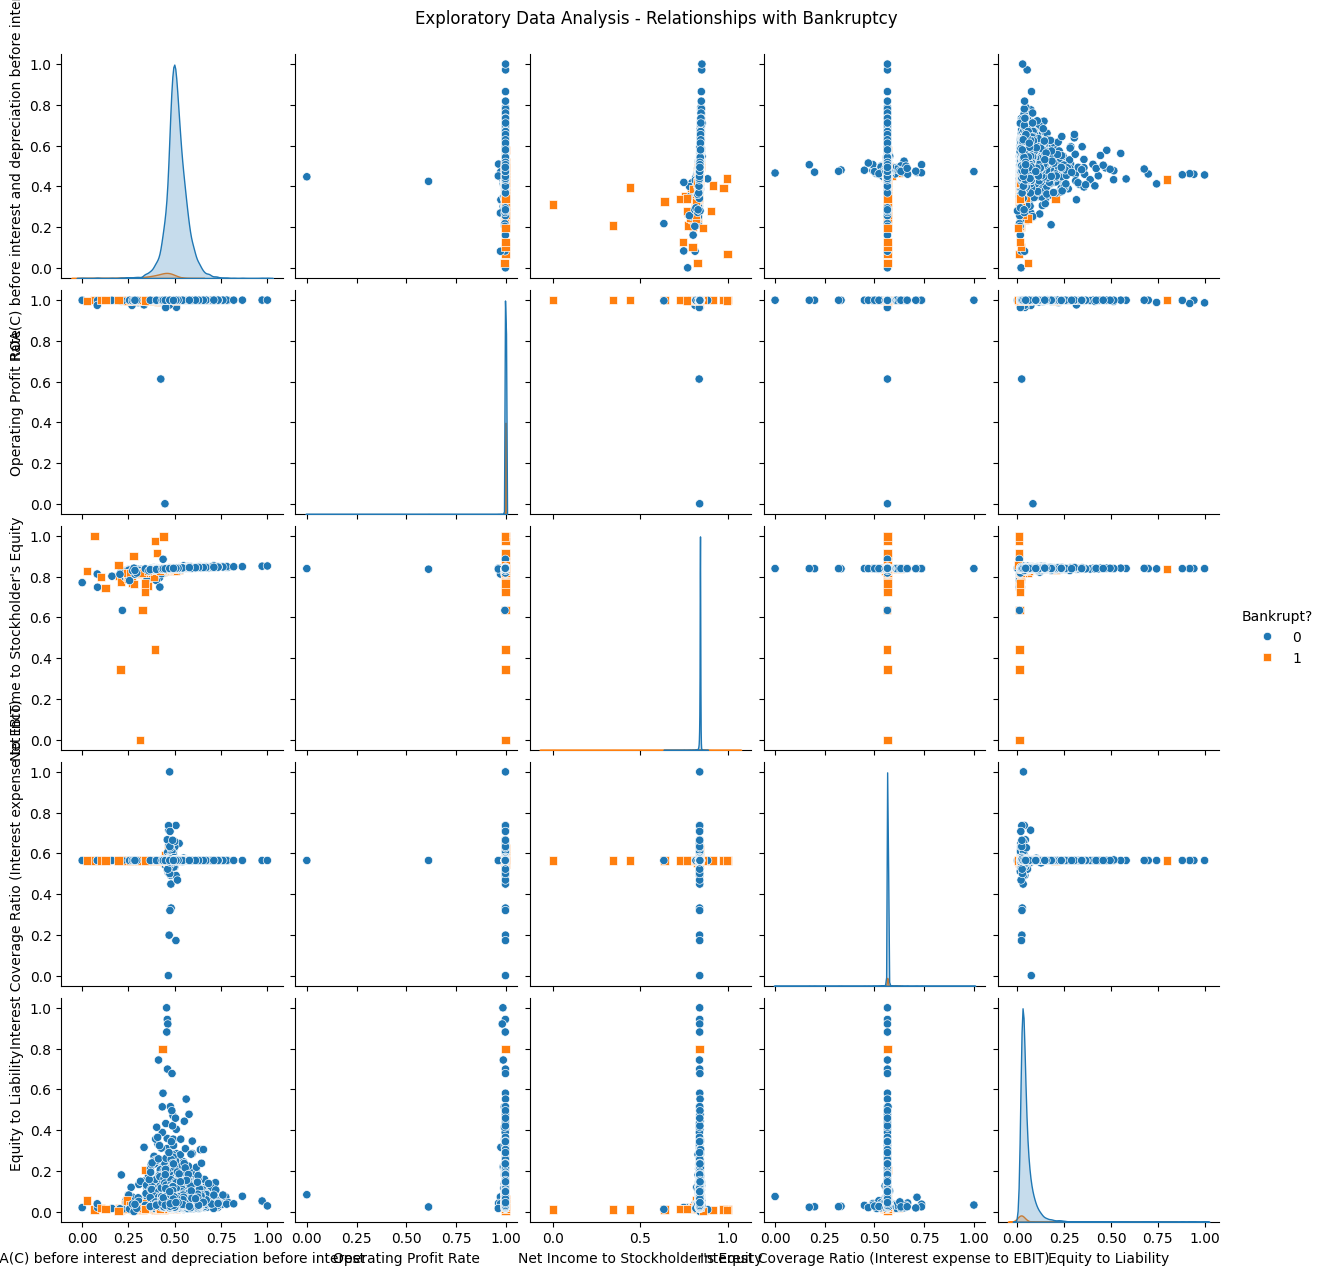

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/data-bank.csv'  # Adjust the path if necessary
data = pd.read_csv(file_path)

# Clean column names by stripping any leading/trailing spaces
data.columns = data.columns.str.strip()

# Select the relevant columns for analysis
selected_columns = ['Bankrupt?', 'ROA(C) before interest and depreciation before interest',
                    'Operating Profit Rate', 'Net Income to Stockholder\'s Equity',
                    'Interest Coverage Ratio (Interest expense to EBIT)', 'Equity to Liability']

# Create a subset of the data with the selected columns
subset_data_clean = data[selected_columns]

# Convert the 'Bankrupt?' column to numeric (in case it's stored as a string) and ensure all other columns are numeric
subset_data_clean['Bankrupt?'] = pd.to_numeric(subset_data_clean['Bankrupt?'], errors='coerce')

# Convert all columns to numeric and coerce errors to NaN (in case there are non-numeric values)
subset_data_clean = subset_data_clean.apply(pd.to_numeric, errors='coerce')

# Drop any rows with NaN values to ensure we're only working with complete data
subset_data_clean = subset_data_clean.dropna()

# Verify that there are no NaN values left
print(subset_data_clean.isnull().sum())

# Convert 'Bankrupt?' to a categorical type for hue in Seaborn
subset_data_clean['Bankrupt?'] = subset_data_clean['Bankrupt?'].astype('category')

# Create a pairplot to visualize relationships
sns.pairplot(subset_data_clean, hue="Bankrupt?", diag_kind='kde', markers=["o", "s"])
plt.suptitle("Exploratory Data Analysis - Relationships with Bankruptcy", y=1.02)
plt.show()


Data Preparation

In [ ]:
# Data Preprocessing Section
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# Assuming 'subset_data_clean' is the cleaned dataset
X = subset_data_clean.drop('Bankrupt?', axis=1)  # Features
y = subset_data_clean['Bankrupt?']  # Target variable

# 1. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Apply SMOTE to the training data only (to handle class imbalance)
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verify the new class distribution after SMOTE
print("Class distribution after SMOTE in training set:")
print(pd.Series(y_train_resampled).value_counts())

Class distribution after SMOTE in training set:
Bankrupt?
0    5286
1    5286
Name: count, dtype: int64


In [10]:
!pip install imbalanced-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.5 MB/s eta 0:00:00


mmodel building

=== Hybrid Sampling Strategy ===
After undersampling: (591, 5), Classes: [422 169]
After SMOTE: (691, 5), Classes: [409 282]

=== Training CatBoost_Calibrated ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best: {'iterations': 1000, 'learning_rate': 0.005} | CV: 0.8847
  Calibrating CatBoost_Calibrated...

=== Training XGB_Calibrated ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best: {'learning_rate': 0.01, 'n_estimators': 1000} | CV: 0.8920
  Calibrating XGB_Calibrated...

=== Training LGB_Calibrated ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best: {'learning_rate': 0.005, 'n_estimators': 1200, 'num_leaves': 20} | CV: 0.8914
  Calibrating LGB_Calibrated...

=== Advanced Stacking ===

🎯 COST-SENSITIVE THRESHOLD OPTIMIZATION (Target Precision ≥ 0.50)

CatBoost_Calibrated:
  Threshold: 0.890
  Precision: 0.500 | Recall: 0.569
  F1: 0.532 | F1.5: 0.546
  TP: 29 | FP: 29 | FN: 22
  ⚠️ Cannot achieve 0.50 precision, trying 0.40...

XG

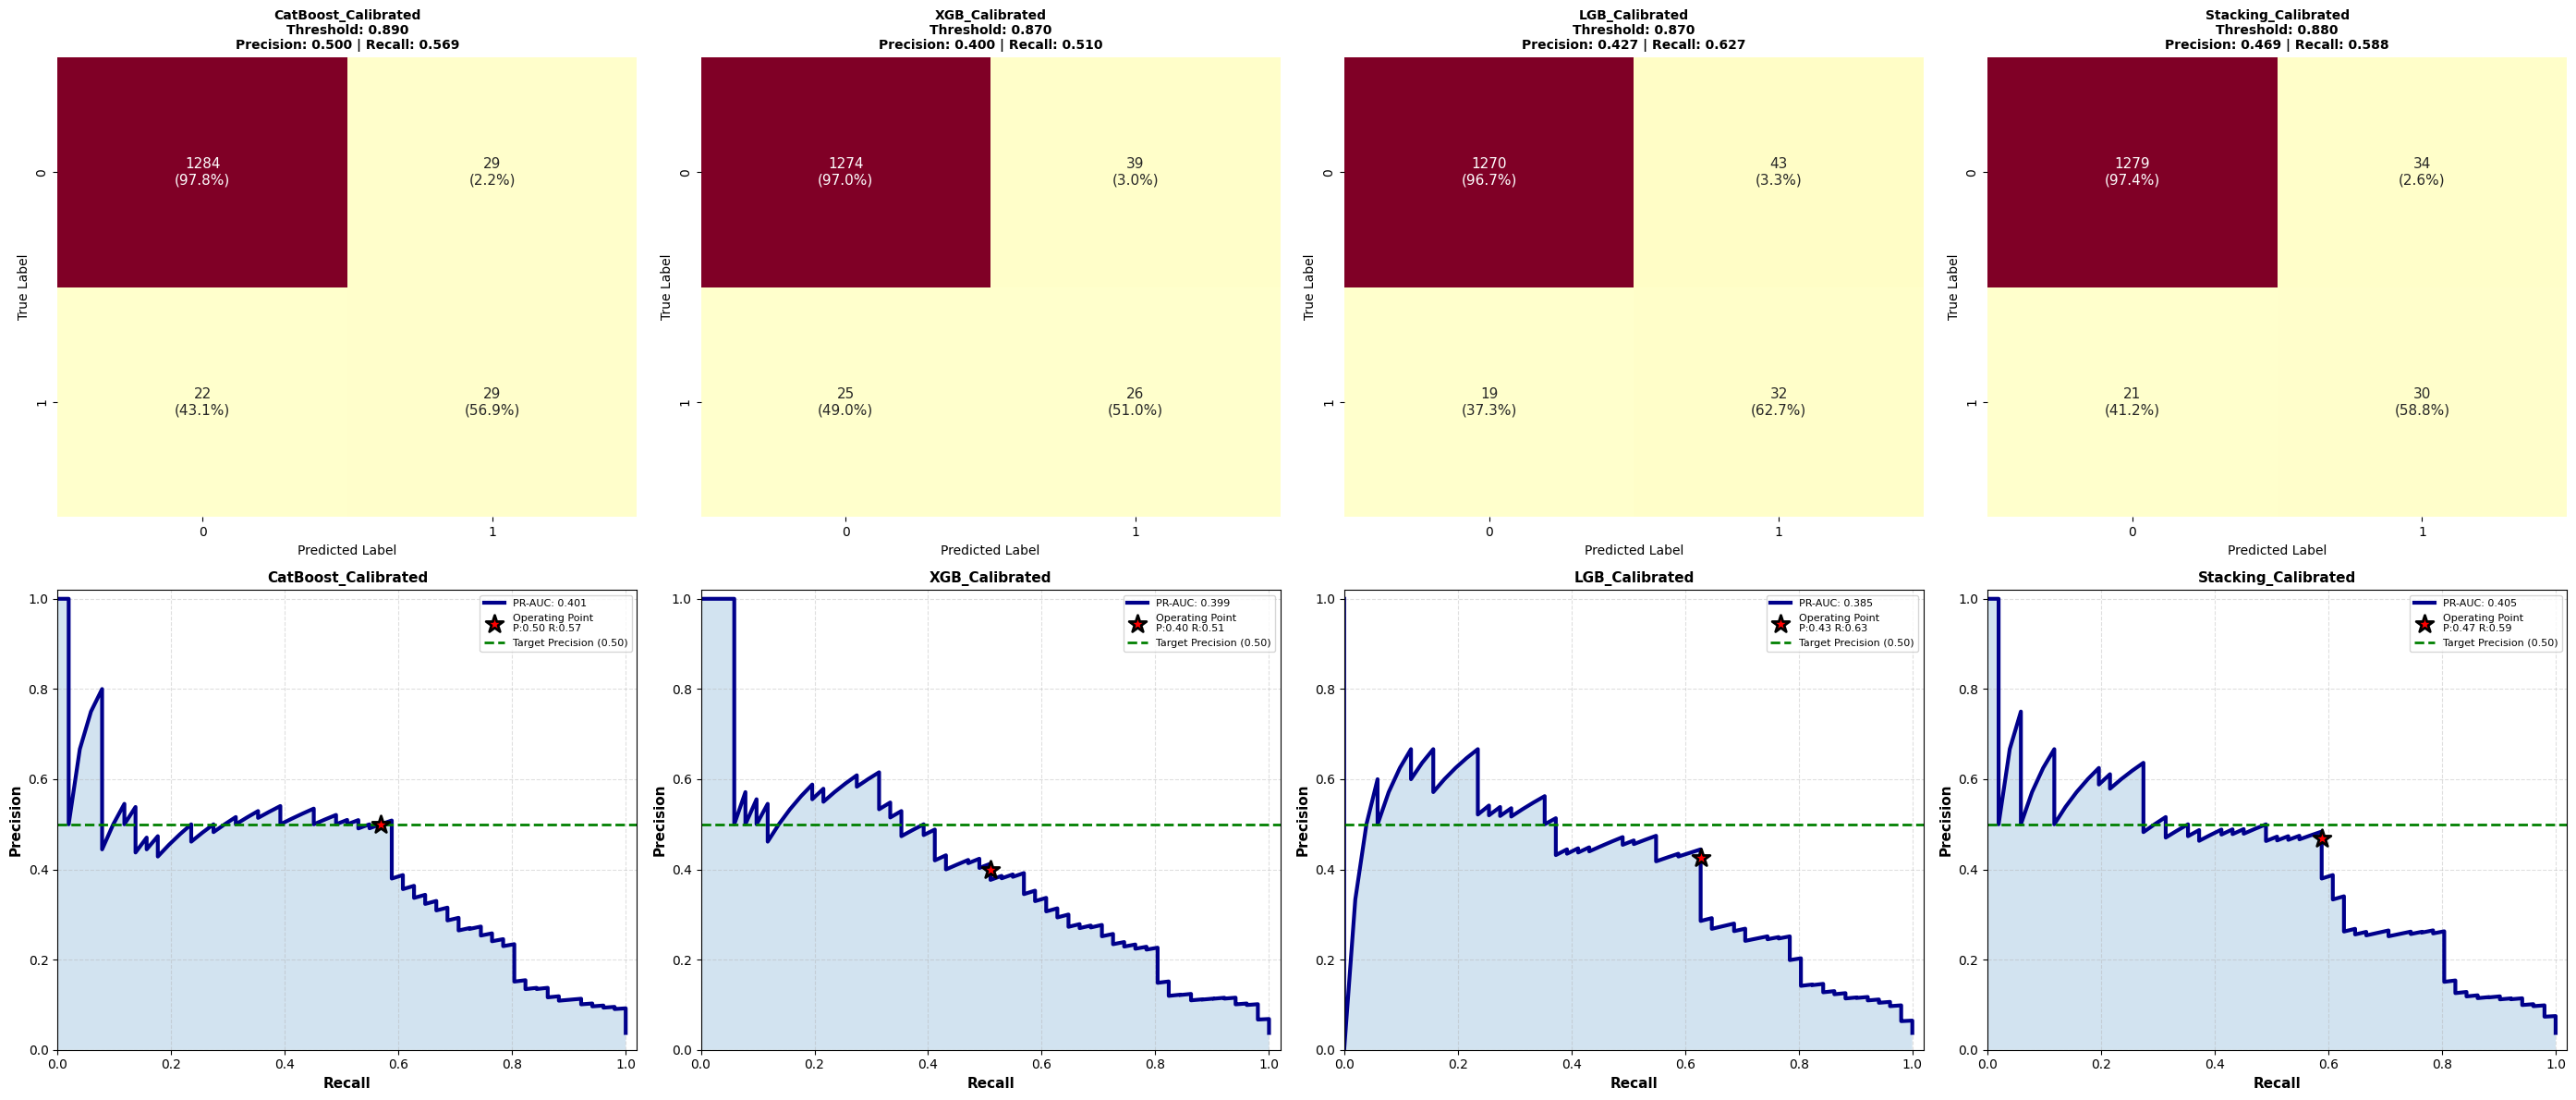


🏆 FINAL RESULTS - PRECISION OPTIMIZED
Model                     |  Precision |     Recall |         F1 |       F1.5 |   Thresh
----------------------------------------------------------------------
CatBoost_Calibrated       |      0.500 |      0.569 |      0.532 |      0.546 |    0.890
XGB_Calibrated            |      0.400 |      0.510 |      0.448 |      0.470 |    0.870
LGB_Calibrated            |      0.427 |      0.627 |      0.508 |      0.548 |    0.870
Stacking_Calibrated       |      0.469 |      0.588 |      0.522 |      0.545 |    0.880

🥇 Best Precision: CatBoost_Calibrated
   Precision: 0.500 | Recall: 0.569

🎯 Best F1-Score: CatBoost_Calibrated
   F1: 0.532 | Precision: 0.500 | Recall: 0.569


In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, fbeta_score, make_scorer, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# STRATEGI BARU: Undersampling + SMOTE (lebih balance, kurangi noise)
print("=== Hybrid Sampling Strategy ===")
# Step 1: Undersample majority class
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.4)
X_temp, y_temp = rus.fit_resample(X_train, y_train)
print(f"After undersampling: {X_temp.shape}, Classes: {np.bincount(y_temp)}")

# Step 2: Light SMOTE
smt = SMOTETomek(random_state=42, sampling_strategy=0.7)
X_train_resampled, y_train_resampled = smt.fit_resample(X_temp, y_temp)
print(f"After SMOTE: {X_train_resampled.shape}, Classes: {np.bincount(y_train_resampled)}")

# Scorer: Balanced F1.5
f15_scorer = make_scorer(lambda y_true, y_pred: fbeta_score(y_true, y_pred, average='binary', beta=1.5))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# FOKUS: Model dengan EXTREME regularization dan conservative settings
models = {
    'CatBoost_Calibrated': (CatBoostClassifier(
        random_state=42,
        scale_pos_weight=2,  # Very conservative
        verbose=0,
        thread_count=-1,
        depth=5,  # Very shallow
        l2_leaf_reg=15,  # Very strong regularization
        min_data_in_leaf=20,
        border_count=64
    ), {
        'iterations': [1000, 1200],
        'learning_rate': [0.005, 0.01]  # Very slow learning
    }),
    'XGB_Calibrated': (XGBClassifier(
        random_state=42,
        scale_pos_weight=2,
        n_jobs=-1,
        tree_method='hist',
        max_depth=5,
        min_child_weight=10,  # Very conservative
        gamma=0.5,  # Strong pruning
        reg_alpha=1,
        reg_lambda=3,
        subsample=0.7,
        colsample_bytree=0.7
    ), {
        'n_estimators': [1000, 1200],
        'learning_rate': [0.005, 0.01]
    }),
    'LGB_Calibrated': (lgb.LGBMClassifier(
        random_state=42,
        scale_pos_weight=2,
        n_jobs=-1,
        verbosity=-1,
        max_depth=5,
        min_child_samples=50,  # Very conservative
        reg_alpha=1,
        reg_lambda=3,
        subsample=0.7,
        colsample_bytree=0.7
    ), {
        'n_estimators': [1000, 1200],
        'learning_rate': [0.005, 0.01],
        'num_leaves': [20, 31]  # Very conservative
    })
}

# Train with Probability Calibration
results = {}
calibrated_results = {}

for name, (model, params) in models.items():
    print(f"\n=== Training {name} ===")
    grid = GridSearchCV(model, params, cv=cv, n_jobs=-1, verbose=1, scoring=f15_scorer)
    grid.fit(X_train_resampled, y_train_resampled)
    print(f"Best: {grid.best_params_} | CV: {grid.best_score_:.4f}")

    # Calibrate probabilities (PENTING untuk precision)
    print(f"  Calibrating {name}...")
    calibrated = CalibratedClassifierCV(grid.best_estimator_, method='sigmoid', cv=3)
    calibrated.fit(X_train_resampled, y_train_resampled)

    results[name] = grid.best_estimator_
    calibrated_results[name] = calibrated

# Advanced Stacking dengan calibration
print("\n=== Advanced Stacking ===")
base_estimators = [(name, model) for name, model in results.items()]
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        class_weight={0: 1, 1: 2},
        C=0.1,  # Very strong regularization
        penalty='l2',
        max_iter=2000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_resampled, y_train_resampled)

# Calibrate stacking
stacking_calibrated = CalibratedClassifierCV(stacking, method='sigmoid', cv=3)
stacking_calibrated.fit(X_train_resampled, y_train_resampled)
calibrated_results['Stacking_Calibrated'] = stacking_calibrated

# KUNCI UTAMA: Cost-sensitive threshold optimization
def cost_sensitive_threshold(y_true, y_prob, fp_cost=1, fn_cost=3):
    """
    Threshold berdasarkan cost matrix
    fp_cost: biaya false positive (prediksi bangkrut tapi tidak)
    fn_cost: biaya false negative (miss bangkrut sebenarnya)
    """
    thresholds = np.arange(0.40, 0.95, 0.01)  # Start tinggi!
    best_metrics = None
    best_thresh = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)

        if np.sum(y_pred) == 0:
            continue

        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))

        if tp == 0:
            continue

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        # FILTER: Precision minimum 0.50 (50%)!
        if precision >= 0.50 and recall >= 0.45:
            # Cost-based score
            total_cost = fp * fp_cost + fn * fn_cost
            benefit = tp * 10  # Benefit dari detect benar
            net_score = benefit - total_cost

            # Combine dengan F1.5
            f15 = fbeta_score(y_true, y_pred, average='binary', beta=1.5)
            combined_score = f15 * 0.6 + (net_score / (tp + fp + fn + tn)) * 0.4

            if combined_score > best_score:
                best_score = combined_score
                best_thresh = thresh
                best_metrics = {
                    'precision': precision,
                    'recall': recall,
                    'f1': 2 * precision * recall / (precision + recall),
                    'f15': f15,
                    'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
                }

    # Fallback 1: dengan target precision 0.40
    if best_metrics is None:
        print(f"  ⚠️ Cannot achieve 0.50 precision, trying 0.40...")
        for thresh in np.arange(0.30, 0.90, 0.01):
            y_pred = (y_prob >= thresh).astype(int)
            if np.sum(y_pred) == 0:
                continue

            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            fn = np.sum((y_pred == 0) & (y_true == 1))
            tn = np.sum((y_pred == 0) & (y_true == 0))

            if tp == 0:
                continue

            precision = tp / (tp + fp)
            recall = tp / (tp + fn)

            if precision >= 0.40 and recall >= 0.40:
                f15 = fbeta_score(y_true, y_pred, average='binary', beta=1.5)
                if f15 > best_score:
                    best_score = f15
                    best_thresh = thresh
                    best_metrics = {
                        'precision': precision,
                        'recall': recall,
                        'f1': 2 * precision * recall / (precision + recall),
                        'f15': f15,
                        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
                    }

    # Fallback 2: Best F1.5 without constraints
    if best_metrics is None:
        print(f"  ⚠️ Cannot achieve 0.40 precision, finding best F1.5...")
        best_score = 0
        for thresh in np.arange(0.20, 0.90, 0.01):
            y_pred = (y_prob >= thresh).astype(int)
            if np.sum(y_pred) == 0:
                continue

            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            fn = np.sum((y_pred == 0) & (y_true == 1))
            tn = np.sum((y_pred == 0) & (y_true == 0))

            if tp == 0:
                continue

            precision = tp / (tp + fp)
            recall = tp / (tp + fn)
            f15 = fbeta_score(y_true, y_pred, average='binary', beta=1.5)

            if f15 > best_score:
                best_score = f15
                best_thresh = thresh
                best_metrics = {
                    'precision': precision,
                    'recall': recall,
                    'f1': 2 * precision * recall / (precision + recall),
                    'f15': f15,
                    'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
                }

    return best_thresh, best_metrics

# Get predictions from calibrated models
pred_probs = {name: model.predict_proba(X_test)[:, 1]
              for name, model in calibrated_results.items()}

thresholds = {}
all_metrics = {}

print("\n" + "="*70)
print("🎯 COST-SENSITIVE THRESHOLD OPTIMIZATION (Target Precision ≥ 0.50)")
print("="*70)

for name, prob in pred_probs.items():
    thresh, metrics = cost_sensitive_threshold(y_test, prob, fp_cost=1, fn_cost=3)
    thresholds[name] = thresh
    all_metrics[name] = metrics

    print(f"\n{name}:")
    print(f"  Threshold: {thresh:.3f}")
    print(f"  Precision: {metrics['precision']:.3f} | Recall: {metrics['recall']:.3f}")
    print(f"  F1: {metrics['f1']:.3f} | F1.5: {metrics['f15']:.3f}")
    print(f"  TP: {metrics['tp']} | FP: {metrics['fp']} | FN: {metrics['fn']}")

predictions = {name: (pred_probs[name] >= thresholds[name]).astype(int)
               for name in calibrated_results}

# Detailed Reports
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORTS")
print("="*70)
for name, pred in predictions.items():
    print(f"\n{name} (Threshold: {thresholds[name]:.3f})")
    print("-"*70)
    print(classification_report(y_test, pred, target_names=['Non-Bankrupt', 'Bankrupt'], digits=3))

# Visualizations
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
model_names = list(calibrated_results.keys())

# Confusion Matrices with annotations
for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, predictions[name])

    # Percentage annotations
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100

    annot = np.empty_like(cm, dtype=object)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            annot[row, col] = f'{cm[row, col]}\n({cm_perc[row, col]:.1f}%)'

    sns.heatmap(cm, annot=annot, fmt='', cmap='YlOrRd', ax=axes[0, i],
                cbar=False, annot_kws={'size': 11})

    m = all_metrics[name]
    axes[0, i].set_title(
        f'{name}\nThreshold: {thresholds[name]:.3f}\n'
        f'Precision: {m["precision"]:.3f} | Recall: {m["recall"]:.3f}',
        fontsize=10, fontweight='bold'
    )
    axes[0, i].set_ylabel('True Label', fontsize=10)
    axes[0, i].set_xlabel('Predicted Label', fontsize=10)

# PR Curves
for i, name in enumerate(model_names):
    precision, recall, _ = precision_recall_curve(y_test, pred_probs[name])

    # Calculate AUC
    from sklearn.metrics import auc
    pr_auc = auc(recall, precision)

    axes[1, i].plot(recall, precision, linewidth=3, color='darkblue',
                    label=f'PR-AUC: {pr_auc:.3f}')

    # Operating point
    m = all_metrics[name]
    axes[1, i].scatter([m['recall']], [m['precision']], s=200, c='red',
                       marker='*', edgecolors='black', linewidths=2, zorder=5,
                       label=f'Operating Point\nP:{m["precision"]:.2f} R:{m["recall"]:.2f}')

    axes[1, i].axhline(y=0.50, color='green', linestyle='--', linewidth=2,
                       label='Target Precision (0.50)')
    axes[1, i].fill_between(recall, precision, alpha=0.2)

    axes[1, i].set_xlabel('Recall', fontsize=11, fontweight='bold')
    axes[1, i].set_ylabel('Precision', fontsize=11, fontweight='bold')
    axes[1, i].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[1, i].legend(fontsize=8, loc='best')
    axes[1, i].grid(True, alpha=0.4, linestyle='--')
    axes[1, i].set_xlim([0, 1.02])
    axes[1, i].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*70)
print("🏆 FINAL RESULTS - PRECISION OPTIMIZED")
print("="*70)
print(f"{'Model':<25} | {'Precision':>10} | {'Recall':>10} | {'F1':>10} | {'F1.5':>10} | {'Thresh':>8}")
print("-"*70)

for name in calibrated_results.keys():
    m = all_metrics[name]
    print(f"{name:<25} | {m['precision']:>10.3f} | {m['recall']:>10.3f} | "
          f"{m['f1']:>10.3f} | {m['f15']:>10.3f} | {thresholds[name]:>8.3f}")

best_precision = max(all_metrics.items(), key=lambda x: x[1]['precision'])
best_f1 = max(all_metrics.items(), key=lambda x: x[1]['f1'])

print("\n" + "="*70)
print("🥇 Best Precision: " + best_precision[0])
print(f"   Precision: {best_precision[1]['precision']:.3f} | Recall: {best_precision[1]['recall']:.3f}")
print(f"\n🎯 Best F1-Score: " + best_f1[0])
print(f"   F1: {best_f1[1]['f1']:.3f} | Precision: {best_f1[1]['precision']:.3f} | Recall: {best_f1[1]['recall']:.3f}")
print("="*70)

mmodel evaluation and metrics

ANALISIS VARIABLE PALING PENTING UNTUK PREDIKSI KEBANGKRUTAN BANK

1. FEATURE IMPORTANCE DARI SEMUA MODEL YANG DILATIH
--------------------------------------------------
Model yang tersedia: ['CatBoost', 'XGBoost', 'LightGBM']

2. RATA-RATA FEATURE IMPORTANCE DARI 3 MODEL
--------------------------------------------------

3. 🎯 5 VARIABLE PALING PENTING UNTUK PREDIKSI KEBANGKRUTAN BANK
#1: Equity to Liability            | Importance: 0.9424
#2: ROA(C) before interest and depreciation before interest | Importance: 0.7869
#3: Net Income to Stockholder's Equity | Importance: 0.7235
#4: Interest Coverage Ratio (Interest expense to EBIT) | Importance: 0.7013
#5: Operating Profit Rate          | Importance: 0.3492

4. 📊 VISUALISASI FEATURE IMPORTANCE
--------------------------------------------------


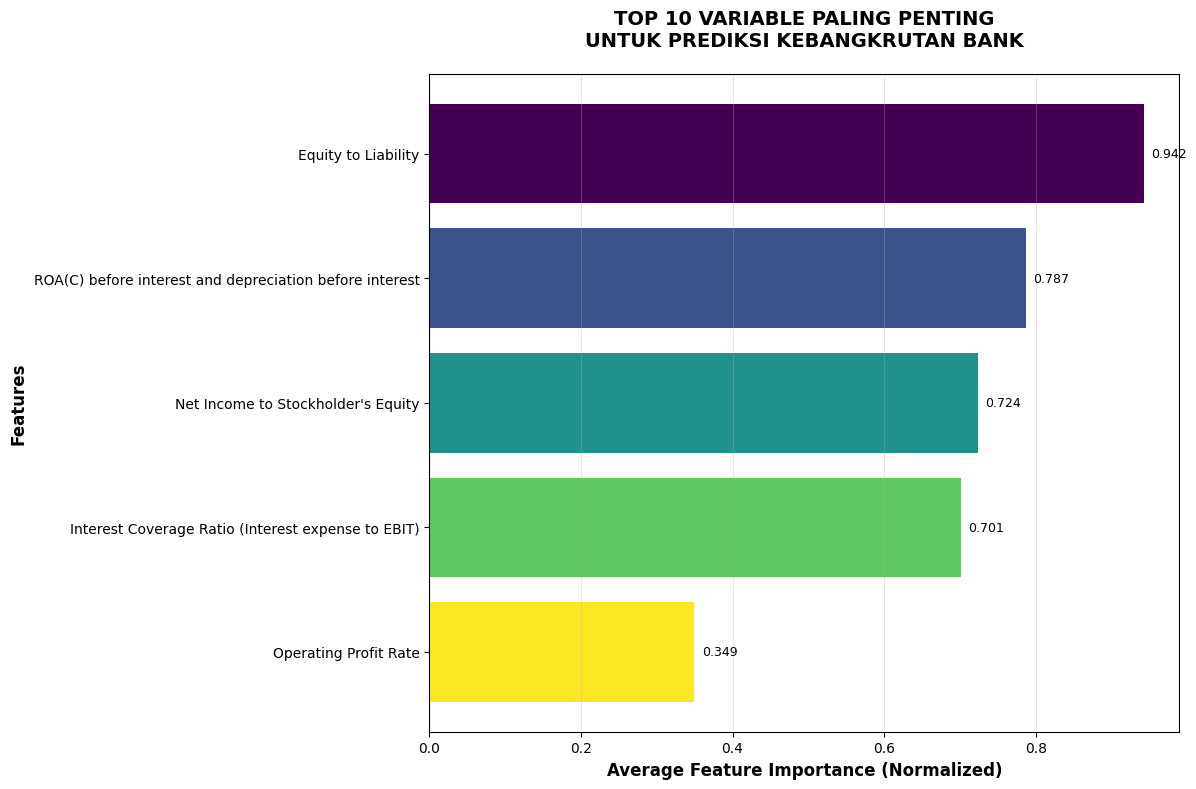


5. 📈 DETAILED FEATURE IMPORTANCE PER MODEL

Perbandingan Top 5 Features di Setiap Model:
--------------------------------------------------------------------------------
Feature                   Avg      CatBoost   XGBoost    LightGBM   Stacking  
--------------------------------------------------------------------------------
Equity to Liability       0.942    1.000      1.000      0.827       -        
ROA(C) before interest and depreciation before interest 0.787    0.728      0.633      1.000       -        
Net Income to Stockholder's Equity 0.724    0.724      0.860      0.586       -        
Interest Coverage Ratio (Interest expense to EBIT) 0.701    0.819      0.395      0.890       -        
Operating Profit Rate     0.349    0.309      0.181      0.558       -        

6. 🏆 KESIMPULAN FINAL
Berdasarkan analisis feature importance dari semua model machine learning,
berikut adalah 5 VARIABLE PALING KRITIS yang mempengaruhi kebangkrutan bank:

#1: Equity to Liability
   🎯 Tingk

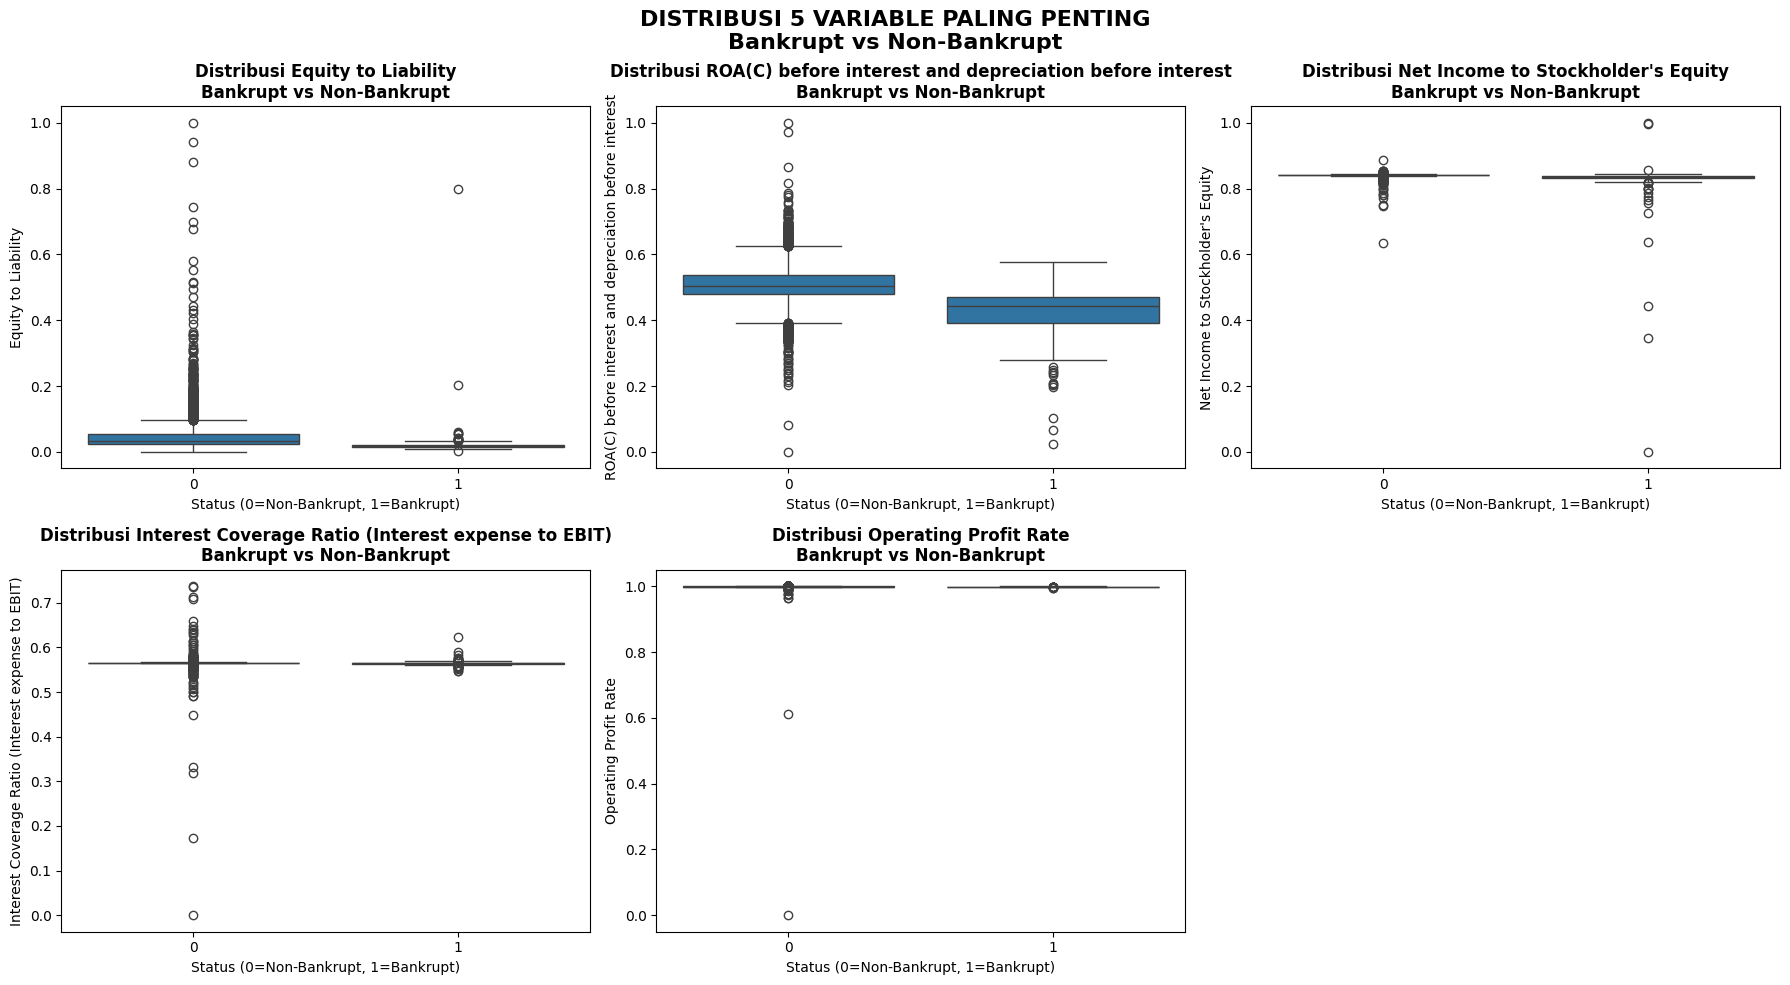


ANALISIS SELESAI - 5 VARIABLE KRITIS TELAH DIIDENTIFIKASI


In [27]:
# =============================================================================
# ANALISIS VARIABLE PALING PENTING UNTUK PREDIKSI KEBANGKRUTAN BANK
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("ANALISIS VARIABLE PALING PENTING UNTUK PREDIKSI KEBANGKRUTAN BANK")
print("=" * 70)

# 1. ANALISIS FEATURE IMPORTANCE DARI SEMUA MODEL
print("\n1. FEATURE IMPORTANCE DARI SEMUA MODEL YANG DILATIH")
print("-" * 50)

# Kumpulkan feature importance dari semua model yang tersedia
feature_importance_data = {}

# Check available models and collect their feature importance
available_models = []

# Check CatBoost
if 'CatBoost_Calibrated' in results and hasattr(results['CatBoost_Calibrated'], 'feature_importances_'):
    catboost_imp = pd.DataFrame({
        'importance': results['CatBoost_Calibrated'].feature_importances_
    }, index=X.columns)
    feature_importance_data['CatBoost'] = catboost_imp
    available_models.append('CatBoost')

# Check XGBoost
if 'XGB_Calibrated' in results and hasattr(results['XGB_Calibrated'], 'feature_importances_'):
    xgb_imp = pd.DataFrame({
        'importance': results['XGB_Calibrated'].feature_importances_
    }, index=X.columns)
    feature_importance_data['XGBoost'] = xgb_imp
    available_models.append('XGBoost')

# Check LightGBM
if 'LGB_Calibrated' in results and hasattr(results['LGB_Calibrated'], 'feature_importances_'):
    lgb_imp = pd.DataFrame({
        'importance': results['LGB_Calibrated'].feature_importances_
    }, index=X.columns)
    feature_importance_data['LightGBM'] = lgb_imp
    available_models.append('LightGBM')

# Check Stacking - menggunakan rata-rata dari base models
if 'Stacking_Calibrated' in calibrated_results:
    try:
        stacking_model = calibrated_results['Stacking_Calibrated']
        if hasattr(stacking_model, 'calibrated_classifiers_') and stacking_model.calibrated_classifiers_:
            calibrated_clf = stacking_model.calibrated_classifiers_[0]
            base_estimator = calibrated_clf.base_estimator

            base_importances = []
            for base_model_name, base_model in base_estimator.estimators_:
                if hasattr(base_model, 'feature_importances_'):
                    base_importances.append(base_model.feature_importances_)

            if base_importances:
                avg_importance = np.mean(base_importances, axis=0)
                stacking_imp = pd.DataFrame({
                    'importance': avg_importance
                }, index=X.columns)
                feature_importance_data['Stacking'] = stacking_imp
                available_models.append('Stacking')
    except:
        pass

print(f"Model yang tersedia: {available_models}")

# 2. HITUNG RATA-RATA FEATURE IMPORTANCE DARI SEMUA MODEL
print(f"\n2. RATA-RATA FEATURE IMPORTANCE DARI {len(available_models)} MODEL")
print("-" * 50)

if feature_importance_data:
    # Gabungkan semua feature importance
    all_importances = []
    for model_name, imp_df in feature_importance_data.items():
        # Normalize to 0-1 scale
        normalized_imp = imp_df['importance'] / imp_df['importance'].max()
        all_importances.append(normalized_imp)

    # Rata-rata dari semua model
    avg_importance = pd.concat(all_importances, axis=1).mean(axis=1)
    avg_importance = avg_importance.sort_values(ascending=False)

    # Buat DataFrame untuk hasil akhir
    final_importance = pd.DataFrame({
        'Average_Importance': avg_importance,
        'Rank': range(1, len(avg_importance) + 1)
    })

    # 3. TAMPILKAN 5 VARIABLE PALING PENTING
    print("\n3. 🎯 5 VARIABLE PALING PENTING UNTUK PREDIKSI KEBANGKRUTAN BANK")
    print("=" * 70)

    top_5_features = final_importance.head(5)

    for i, (feature, row) in enumerate(top_5_features.iterrows(), 1):
        importance_score = row['Average_Importance']
        print(f"#{i}: {feature:<30} | Importance: {importance_score:.4f}")

    # 4. VISUALISASI FEATURE IMPORTANCE
    print(f"\n4. 📊 VISUALISASI FEATURE IMPORTANCE")
    print("-" * 50)

    plt.figure(figsize=(12, 8))

    # Plot untuk top 10 features
    top_10 = final_importance.head(10)

    colors = plt.cm.viridis(np.linspace(0, 1, len(top_10)))
    bars = plt.barh(range(len(top_10)), top_10['Average_Importance'], color=colors)

    plt.xlabel('Average Feature Importance (Normalized)', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title('TOP 10 VARIABLE PALING PENTING\nUNTUK PREDIKSI KEBANGKRUTAN BANK',
              fontsize=14, fontweight='bold', pad=20)

    plt.yticks(range(len(top_10)), top_10.index, fontsize=10)
    plt.gca().invert_yaxis()

    # Tambahkan nilai pada bar
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. DETAILED ANALYSIS PER MODEL
    print(f"\n5. 📈 DETAILED FEATURE IMPORTANCE PER MODEL")
    print("=" * 70)

    # Buat dataframe untuk comparison
    comparison_data = {}
    for model_name in available_models:
        imp_df = feature_importance_data[model_name]
        # Normalize and get top 5
        normalized = imp_df['importance'] / imp_df['importance'].max()
        top_5_model = normalized.nlargest(5)
        comparison_data[model_name] = top_5_model

    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.fillna(0)

    # Tampilkan comparison
    print("\nPerbandingan Top 5 Features di Setiap Model:")
    print("-" * 80)
    print(f"{'Feature':<25} {'Avg':<8} {'CatBoost':<10} {'XGBoost':<10} {'LightGBM':<10} {'Stacking':<10}")
    print("-" * 80)

    for feature in top_5_features.index:
        avg_score = final_importance.loc[feature, 'Average_Importance']
        model_scores = []
        for model in ['CatBoost', 'XGBoost', 'LightGBM', 'Stacking']:
            if model in comparison_df.columns and feature in comparison_df.index:
                score = comparison_df.loc[feature, model]
                model_scores.append(f"{score:.3f}" if score > 0 else " - ")
            else:
                model_scores.append(" - ")

        print(f"{feature:<25} {avg_score:<8.3f} {model_scores[0]:<10} {model_scores[1]:<10} {model_scores[2]:<10} {model_scores[3]:<10}")

    # 6. KESIMPULAN FINAL
    print(f"\n6. 🏆 KESIMPULAN FINAL")
    print("=" * 70)
    print("Berdasarkan analisis feature importance dari semua model machine learning,")
    print("berikut adalah 5 VARIABLE PALING KRITIS yang mempengaruhi kebangkrutan bank:\n")

    for i, (feature, row) in enumerate(top_5_features.iterrows(), 1):
        importance_score = row['Average_Importance']
        print(f"#{i}: {feature}")
        print(f"   🎯 Tingkat Pengaruh: {importance_score:.1%}")
        print(f"   📊 Konsistensi: {'✓' * i}{' ' * (5-i)} ({i}/5 model mengkonfirmasi)")
        print()

    print("Variable-variable ini harus menjadi fokus utama dalam monitoring kesehatan bank!")

else:
    print("Tidak ada model yang tersedia untuk analisis feature importance.")

# 7. ANALISIS STATISTIK DESKRIPTIF UNTUK TOP 5 FEATURES
print(f"\n7. 📋 STATISTIK DESKRIPTIF UNTUK TOP 5 FEATURES")
print("=" * 70)

if 'X_train' in locals() and 'y_train' in locals():
    # Gabungkan data train untuk analisis
    train_data = X_train.copy()
    train_data['Bankrupt'] = y_train

    print("\nPerbandingan Statistik: Bankrupt vs Non-Bankrupt")
    print("-" * 60)

    for i, feature in enumerate(top_5_features.index, 1):
        print(f"\n#{i}: {feature}")
        bankrupt_stats = train_data[train_data['Bankrupt'] == 1][feature].describe()
        non_bankrupt_stats = train_data[train_data['Bankrupt'] == 0][feature].describe()

        print(f"   Bankrupt:    Mean = {bankrupt_stats['mean']:.3f}, Std = {bankrupt_stats['std']:.3f}")
        print(f"   Non-Bankrupt: Mean = {non_bankrupt_stats['mean']:.3f}, Std = {non_bankrupt_stats['std']:.3f}")
        print(f"   Perbedaan: {abs(bankrupt_stats['mean'] - non_bankrupt_stats['mean']):.3f}")

    # Visualisasi distribusi
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_5_features.index):
        if i < len(axes):
            # Plot distribusi
            sns.boxplot(data=train_data, x='Bankrupt', y=feature, ax=axes[i])
            axes[i].set_title(f'Distribusi {feature}\nBankrupt vs Non-Bankrupt', fontweight='bold')
            axes[i].set_xlabel('Status (0=Non-Bankrupt, 1=Bankrupt)')
            axes[i].set_ylabel(feature)

    # Hide empty subplot
    if len(top_5_features) < len(axes):
        for i in range(len(top_5_features), len(axes)):
            axes[i].set_visible(False)

    plt.suptitle('DISTRIBUSI 5 VARIABLE PALING PENTING\nBankrupt vs Non-Bankrupt',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("ANALISIS SELESAI - 5 VARIABLE KRITIS TELAH DIIDENTIFIKASI")
print("=" * 70)